<a href="https://colab.research.google.com/github/senuja-dilmith/EN3150_A03_GalTricals/blob/main/Assignment3_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3150 Assignment 03: Resource-Constrained CNN for Edge Image Classification

**Group Members:**
- CHINTHAKA M.K.M.G. - 230105H
- DILMITH GS - 230149U
- KAUSHAL S.V. - 230326K
- RAJAPAKSHA J.S.W. - 230511A

## 1. Introduction & Data Preparation

For this assignment, we are tasked with building a lightweight image classifier designed for embedded or low-resource devices (e.g. edge nodes, microcontrollers).

We have selected the **TF Flowers dataset**, which contains images of 5 different flower classes.

**Preprocessing & Downscaling:**
As per the assignment guidelines, to emulate a low-resource sensor environment, we explicitly **downscale the original images to a resolution of 64x64 pixels** during the loading process. This constraint is critical for testing our lightweight CNN architectures.

**Data Split Strategy:**
The dataset is split into three subsets:
- **Training Set (70%):** Used for learning the features and updating model weights.
- **Validation Set (15%):** Used for hyperparameter tuning and preventing overfitting.
- **Testing Set (15%):** Held out completely for an unbiased final evaluation.

TensorFlow Version: 2.20.0
228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Loading and downscaling images to 64x64...
Found 3670 files belonging to 5 classes.
Using 2569 files for training.
Found 3670 files belonging to 5 classes.
Using 1101 files for validation.

Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Training batches: 81
Validation batches: 17
Testing batches: 18


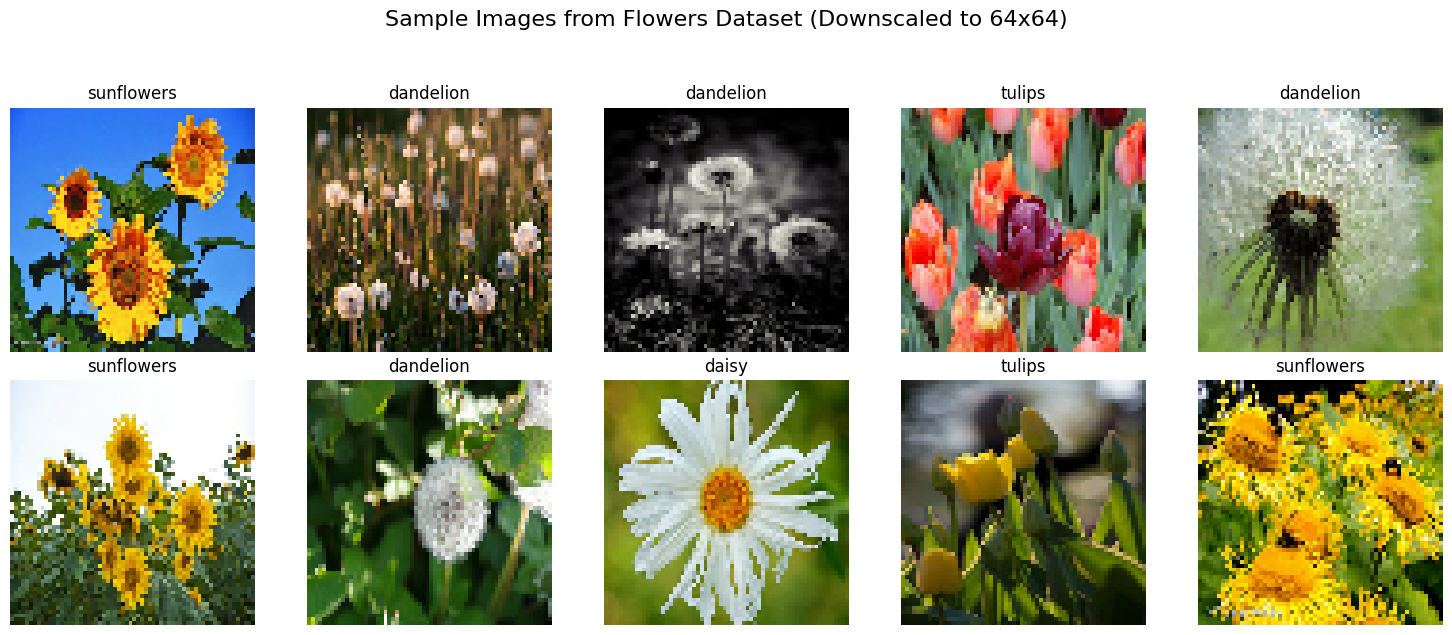

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os

# Set random seeds for reproducibility
tf.keras.utils.set_random_seed(42)

print("TensorFlow Version:", tf.__version__)

# 1. Download and Load the Dataset (TF Flowers)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# Fix for the "1 class" issue: Move one folder level deeper if extracted incorrectly
subdirs = [os.path.join(data_dir_path, d) for d in os.listdir(data_dir_path) if os.path.isdir(os.path.join(data_dir_path, d))]
if len(subdirs) == 1:
    data_dir_path = subdirs[0]

data_dir = pathlib.Path(data_dir_path)

# 2. Emulate low-resource sensor environment by downscaling to 64x64
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

print("Loading and downscaling images to 64x64...")

# Load 70% as Training Data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30, # Reserve 30% for Val/Test
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# [FIX]: Save class names BEFORE we modify (map) the dataset
class_names = train_dataset.class_names

# Load 30% as Validation Data
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 30% into 15% Validation and 15% Test
val_test_batches = tf.data.experimental.cardinality(val_test_dataset)
val_batches = val_test_batches // 2

val_dataset = val_test_dataset.take(val_batches)
test_dataset = val_test_dataset.skip(val_batches)

print(f"\nClasses found: {class_names}")
print(f"Training batches: {tf.data.experimental.cardinality(train_dataset)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_dataset)}")
print(f"Testing batches: {tf.data.experimental.cardinality(test_dataset)}")

# 3. Preprocessing (Normalization)
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply normalization
train_dataset = train_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# 4. Visualize some samples
plt.figure(figsize=(15, 6))
# Using the class_names we saved earlier
for images, labels in train_dataset.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Images from Flowers Dataset (Downscaled to 64x64)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()